# Dataset distributions — 4-way side-by-side

`datasets_llama2` · `datasets_llama2_sample2` · `datasets_claudeopus_sample2` · `datasets_sol_100`

All four directories hold the same artifact type: synthetic `HUMAN:` / `ASSISTANT:` conversations
generated to express one of four behavioural attributes — **gullibility**, **rationality**,
**seriousness**, **certainty_seeking** — at a discrete level (`low` / `medium` (or `neutral` for
`certainty_seeking`) / `high`). They are the training corpora for the probes in `src/`.

**What this notebook covers:** where each dataset came from (generator model, script, exact
generation prompt), how many conversations it holds, how those are distributed over
attribute × level, how much of it is unique, and how the conversations are shaped (turns, message
length, vocabulary). Every chart is a direct 4-way comparison and every chart has a table beside it.

**What it does not cover:** whether the low/medium/high manipulation actually lands — that is a
probe-accuracy question, not a distribution question.

## 0 · Setup

Colours are fixed once here and reused in every chart: one hue per dataset (categorical, assigned in
a fixed order — never recycled), and a single-hue light→dark ramp for the ordered `low → medium/neutral → high`
levels. Bars carry their value as a printed label throughout.

In [1]:
import ast
import difflib
import hashlib
import json
import random
import re
import textwrap
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 220)

INK, MUTED, FAINT = "#0b0b0b", "#52514e", "#8a8983"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c4", "axes.axisbelow": True,
    "axes.grid": True, "grid.color": "#e8e7e4", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "figure.titlesize": 13,
    "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "legend.frameon": False,
})

ROOT = Path("..")

# dataset name -> (directory, generator model, generation script)
DATASETS = {
    "llama2":              (ROOT / "datasets_llama2",              "Llama-2-13b-chat", "scripts/gen_llama_dataset.py"),
    "llama2_sample2":      (ROOT / "datasets_llama2_sample2",      "Llama-2-13b-chat", "scripts/build_llama2_sample2.py"),
    "claudeopus_sample2":  (ROOT / "datasets_claudeopus_sample2",  "claude-opus-5",    "scripts/gen_opus_data100.py"),
    "sol_100":             (ROOT / "datasets_sol_100",             "gpt-5.6-sol",      "scripts/gen_sol_data100.py"),
}
DS_ORDER = list(DATASETS)
ATTRS = ["gullibility", "rationality", "seriousness", "certainty_seeking"]

# Categorical palette, fixed slot order (blue, orange, aqua, yellow) — validated for
# colour-vision-deficiency separation on adjacent pairs; every bar is also value-labelled.
PALETTE = dict(zip(DS_ORDER, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
# Ordinal single-hue ramp for the ordered levels.
LEVEL_ORDER = ["low", "medium", "neutral", "high"]
LEVEL_COLOR = {"low": "#86b6ef", "medium": "#2a78d6", "neutral": "#2a78d6", "high": "#104281"}
SLOT_ORDER = ["low", "mid", "high"]
SLOT_LABEL = {"low": "low", "mid": "medium  (= neutral for certainty_seeking)", "high": "high"}
SLOT_COLOR = {"low": "#86b6ef", "mid": "#2a78d6", "high": "#104281"}
LEVEL_SLOT = {"low": "low", "medium": "mid", "neutral": "mid", "high": "high"}


def label_bars(ax, fmt="{:.0f}", fontsize=8, rotation=0):
    """Print each bar's value on top of it (or at the end, for horizontal bars)."""
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=2, fontsize=fontsize,
                     color=INK, rotation=rotation)
    ax.margins(y=0.15)


def style_axes(ax, ylabel=None, title=None):
    ax.grid(axis="x", visible=False)
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, color=INK)
    ax.set_xlabel("")
    return ax


print("datasets:", ", ".join(DS_ORDER))

datasets: llama2, llama2_sample2, claudeopus_sample2, sol_100


## 1 · Provenance — where each dataset came from

| dataset | generator | script | how it was invoked |
|---|---|---|---|
| `datasets_llama2` | `NousResearch/Llama-2-13b-chat-hf`, local GPU | [`scripts/gen_llama_dataset.py`](../scripts/gen_llama_dataset.py) | `python scripts/gen_llama_dataset.py --num_samples 500` |
| `datasets_llama2_sample2` | *none* — derived | [`scripts/build_llama2_sample2.py`](../scripts/build_llama2_sample2.py) | `python scripts/build_llama2_sample2.py` (dedupes `datasets_llama2`, renumbers files) |
| `datasets_claudeopus_sample2` | `claude-opus-5` via `api.opusgate.dev` | [`scripts/gen_opus_data100.py`](../scripts/gen_opus_data100.py) | [`scripts/gen_opus_data100.sh`](../scripts/gen_opus_data100.sh) → `--per_level 100 --output_dir datasets_claudeopus_sample2` |
| `datasets_sol_100` | `gpt-5.6-sol` via `api.opusgate.dev/v1` | [`scripts/gen_sol_data100.py`](../scripts/gen_sol_data100.py) | `python scripts/gen_sol_data100.py --per_level 100` (default `--output_dir datasets_sol_100`) |

Supporting files: `scripts/find_llama2_duplicates.py` wrote `datasets_llama2/duplicate_files.json`;
`datasets_claudeopus_sample2/run.log` + `run.pid` are the resumable batch job's log.
`gen_opus_data100.py` and `gen_sol_data100.py` are the *same program* — they differ only in the API
client, model name and token pricing.

In [2]:
prov = pd.DataFrame(
    [
        {
            "dataset": name,
            "directory": str(path).replace("../", ""),
            "generator model": model,
            "generation script": script,
            "per-conversation .json sidecar": "yes" if any(path.glob("*/*.json")) else "no",
        }
        for name, (path, model, script) in DATASETS.items()
    ]
).set_index("dataset")

for f in ["run.log", "run.pid", "duplicate_files.json"]:
    prov[f] = ["yes" if (DATASETS[n][0] / f).exists() else "—" for n in prov.index]

prov

,directory,generator model,generation script,per-conversation .json sidecar,run.log,run.pid,duplicate_files.json
dataset,,,,,,,
llama2,datasets_llama2,Llama-2-13b-chat,scripts/gen_llama_dataset.py,no,—,—,yes
llama2_sample2,datasets_llama2_sample2,Llama-2-13b-chat,scripts/build_llama2_sample2.py,no,—,—,—
claudeopus_sample2,datasets_claudeopus_sample2,claude-opus-5,scripts/gen_opus_data100.py,yes,yes,yes,—
sol_100,datasets_sol_100,gpt-5.6-sol,scripts/gen_sol_data100.py,yes,—,—,—


## 2 · The generation prompts

Two different prompting regimes produced these datasets:

* **`datasets_llama2`** (and therefore its derivative `llama2_sample2`) — a **static, one-conversation-at-a-time**
  prompt. `build_prompt(attribute, level)` in `scripts/gen_llama_dataset.py` composes a single
  `SYSTEM:` line from the attribute spec; there are exactly **12** distinct prompts (4 attributes × 3
  levels) and every conversation in the directory came from one of them. Nothing is recorded on disk
  per conversation, so the prompt is reconstructed here from the script.
* **`datasets_claudeopus_sample2`, `datasets_sol_100`** — a **batched JSON** prompt.
  `build_prompt(attribute, per_level, rng)` asks for *N conversations per level in one call*, returns
  strict JSON, and seeds each batch with randomly sampled topic domains / conversation shapes / user
  voices, so **every batch gets a different prompt**. The exact prompt used is stored verbatim in each
  conversation's `.json` sidecar.

The **level definitions themselves are shared** — the `ATTRIBUTES` dict (persona, behaviour,
`show_through` channel, leak stems) is byte-identical in all three generator scripts, verified below.
So the personas being trained on are the same; what differs is the generator model and the prompt
scaffolding around those personas.

In [3]:
def load_literal(script_path, name):
    """Pull a module-level literal (e.g. ATTRIBUTES) out of a script without importing it —
    the generator scripts import torch / anthropic / openai, which we do not need here."""
    tree = ast.parse((ROOT / script_path).read_text())
    for node in tree.body:
        if isinstance(node, ast.Assign) and getattr(node.targets[0], "id", None) == name:
            return ast.literal_eval(node.value)
    raise KeyError(f"{name} not found in {script_path}")


ATTR_SPEC = load_literal("scripts/gen_llama_dataset.py", "ATTRIBUTES")
opus_spec = load_literal("scripts/gen_opus_data100.py", "ATTRIBUTES")
sol_spec = load_literal("scripts/gen_sol_data100.py", "ATTRIBUTES")

print("ATTRIBUTES spec identical in gen_llama_dataset.py / gen_opus_data100.py / gen_sol_data100.py:",
      ATTR_SPEC == opus_spec == sol_spec)

spec_table = pd.DataFrame(
    [
        {
            "attribute": attr,
            "levels": " / ".join(cfg["levels"]),
            "expressed through": cfg["show_through"],
            "leak stems (post-hoc check, never sent to the model)": ", ".join(cfg["leak_stems"]),
        }
        for attr, cfg in ATTR_SPEC.items()
    ]
).set_index("attribute")
spec_table

ATTRIBUTES spec identical in gen_llama_dataset.py / gen_opus_data100.py / gen_sol_data100.py: True


,levels,expressed through,"leak stems (post-hoc check, never sent to the model)"
attribute,,,
gullibility,low / medium / high,how the user reacts to the assistant's claims and advice,"gullib, credul, skeptic, sceptic, naive, naïve, trust"
rationality,low / medium / high,how the user frames requests and responds to the answers they get,"rational, irrational, logic, reasonab"
seriousness,low / medium / high,"the user's tone, word choice, and the stakes of what they ask about","serious, silly, jok, formal"
certainty_seeking,low / neutral / high,how the user reacts when the assistant gives a hedged or open-ended answer,"certain, uncertain, ambigu, unsure"


In [4]:
persona_table = pd.DataFrame(
    [
        {"attribute": attr, "level": lv,
         "persona (\"This human user …\")": cfg["persona"][lv],
         "behaviour": cfg["behavior"][lv]}
        for attr, cfg in ATTR_SPEC.items() for lv in cfg["levels"]
    ]
).set_index(["attribute", "level"])
persona_table

persona ("This human user …")                                                                                            behaviour
attribute         level                                                                                                                                                                             
gullibility       low                                        rarely takes a claim at face value  they ask where information comes from, push back when something sounds unsupported, and want to ...
                  medium   goes along with most of what they are told, with occasional pushback  they generally act on the assistant's answers, but now and then ask a clarifying question or wan...
                  high                                   takes what they are told at face value  they accept the assistant's claims without asking where the information comes from, and may rest...
rationality       low                 jumps to conclusions and argues from feeling and anecdote  they generalise from a single story, hold on to a position when given evidence against it, and m...
                  medium                                 thinks things through most of the time              they usually weigh the options, but sometimes build on an assumption they never checked
                  high                      weighs evidence carefully before settling on a view  they ask what a claim is based on, name the trade-offs explicitly, and change their position whe...
seriousness       low                                            keeps things light and playful  they use puns and wordplay, pose absurd hypotheticals, write in casual slang, and are happy with...
                  medium                  is mostly down to business, with the occasional aside       they ask practical questions and want usable answers, but will play along with a bit of levity
                  high                                     treats the exchange as consequential  they write in a measured, professional register, ask about matters with real stakes — health, le...
certainty_seeking low                 is comfortable when a question has no single right answer  they accept "it depends" or a range of possible outcomes without pressing further, and are conte...
                  neutral              usually accepts a hedged answer, but likes a bottom line          they are fine with caveats, though they will sometimes ask the assistant for its best guess
                  high                                  wants one definite answer to everything  they push back on caveats and hedging, ask again for one clear conclusion, and press for a firm ...

### 2.1 · `datasets_llama2` — the exact prompt (reconstructed from the script)

Mirrors `build_prompt()` at [`scripts/gen_llama_dataset.py:233`](../scripts/gen_llama_dataset.py).
Shown for `gullibility` / `low`; the other 11 differ only in the persona and behaviour clauses from
the table above.

In [5]:
END_TAG = "<End of Conversation>"  # scripts/gen_llama_dataset.py


def llama_build_prompt(attribute_name, level):
    """Verbatim reimplementation of build_prompt() in scripts/gen_llama_dataset.py."""
    cfg = ATTR_SPEC[attribute_name]
    persona, behavior = cfg["persona"][level], cfg["behavior"][level]
    show_through = cfg["show_through"]
    return (
        "SYSTEM: Generate a conversation between a human user and an AI assistant. "
        f"This human user {persona}: {behavior}. "
        f"Convey this through {show_through} — the user should never name or "
        "describe this characteristic about themselves. "
        "Be creative on the topics of conversation. "
        "Make the conversation sound natural. "
        "The user's response should start with 'HUMAN:', and the AI assistant's "
        "response should start with 'ASSISTANT:'. "
        f"Mark the end of the generated conversation with '{END_TAG}'"
    )


LLAMA_PROMPTS = {(a, lv): llama_build_prompt(a, lv) for a, c in ATTR_SPEC.items() for lv in c["levels"]}
print(f"{len(LLAMA_PROMPTS)} distinct prompts total ({len(ATTR_SPEC)} attributes x 3 levels)\n")
print(textwrap.fill(LLAMA_PROMPTS[("gullibility", "low")], 100))

12 distinct prompts total (4 attributes x 3 levels)

SYSTEM: Generate a conversation between a human user and an AI assistant. This human user rarely
takes a claim at face value: they ask where information comes from, push back when something sounds
unsupported, and want to see evidence before acting on advice. Convey this through how the user
reacts to the assistant's claims and advice — the user should never name or describe this
characteristic about themselves. Be creative on the topics of conversation. Make the conversation
sound natural. The user's response should start with 'HUMAN:', and the AI assistant's response
should start with 'ASSISTANT:'. Mark the end of the generated conversation with '<End of
Conversation>'


In [6]:
# The prompt is then wrapped in the Llama-2 chat template before generation
# (llama_v2_prompt from TalkTuner's dataset.py, called in gen_llama_dataset.py), and
# generation is capped at --max_new_tokens 768 with a stop on the end tag.
for (attr, lv), p in list(LLAMA_PROMPTS.items())[:3]:
    print(f"--- {attr} / {lv} " + "-" * 60)
    print(textwrap.fill(p, 100), "\n")

--- gullibility / low ------------------------------------------------------------
SYSTEM: Generate a conversation between a human user and an AI assistant. This human user rarely
takes a claim at face value: they ask where information comes from, push back when something sounds
unsupported, and want to see evidence before acting on advice. Convey this through how the user
reacts to the assistant's claims and advice — the user should never name or describe this
characteristic about themselves. Be creative on the topics of conversation. Make the conversation
sound natural. The user's response should start with 'HUMAN:', and the AI assistant's response
should start with 'ASSISTANT:'. Mark the end of the generated conversation with '<End of
Conversation>' 

--- gullibility / medium ------------------------------------------------------------
SYSTEM: Generate a conversation between a human user and an AI assistant. This human user goes along
with most of what they are told, with occasional

### 2.2 · `datasets_claudeopus_sample2` / `datasets_sol_100` — the exact prompt (read from a sidecar)

This is the real prompt string that produced the conversation named in the header — recovered from
its `.json` sidecar, not reconstructed. Both datasets use the identical template
(`build_prompt()` at [`scripts/gen_opus_data100.py:327`](../scripts/gen_opus_data100.py) and
[`scripts/gen_sol_data100.py:327`](../scripts/gen_sol_data100.py)); what varies from call to call is
the sampled seed lists at the bottom. Both scripts also share a base seed (`75241239`), so they walk
the same sequence of sampled batches — quantified below.

In [7]:
def first_sidecar(ds_name, attr="gullibility"):
    path = sorted((DATASETS[ds_name][0] / attr).glob("*_low.json"))[0]
    return path, json.loads(path.read_text())


for ds in ["claudeopus_sample2", "sol_100"]:
    path, meta = first_sidecar(ds)
    print("=" * 100)
    print(f"{ds}  <-  {str(path).replace('../', '')}")
    print(f"model={meta['model']}  seed={meta['seed']}  call_index={meta['call_index']}  "
          f"generated_at={meta['generated_at']}")
    print("=" * 100)
    print(meta["prompt"])
    print()

claudeopus_sample2  <-  datasets_claudeopus_sample2/gullibility/conversation_0_gullibility_low.json
model=claude-opus-5  seed=75241239  call_index=1  generated_at=2026-09-06T15:03:37.004151+00:00
You are generating a synthetic dataset of conversations between a human user and an AI assistant, to study one behavioural attribute: **gullibility**.

This attribute has 3 levels. The *only* thing that should differ between levels is how the user reacts to the assistant's claims and advice. Everything else — subject matter, tone, conversation length, assistant helpfulness — should be equally varied across all levels.

Levels:
  - level "low": the user rarely takes a claim at face value: they ask where information comes from, push back when something sounds unsupported, and want to see evidence before acting on advice.
  - level "medium": the user goes along with most of what they are told, with occasional pushback: they generally act on the assistant's answers, but now and then ask a clarifyi

In [8]:
# Both API generators share a base seed, so they draw the same batch prompts —
# which makes claudeopus_sample2 vs sol_100 close to a controlled model comparison.
prompt_sets = {}
for ds in ["claudeopus_sample2", "sol_100"]:
    prompt_sets[ds] = {
        hashlib.sha256(json.loads(p.read_text())["prompt"].encode()).hexdigest()
        for p in DATASETS[ds][0].rglob("*.json")
    }
shared = prompt_sets["claudeopus_sample2"] & prompt_sets["sol_100"]
print(f'claudeopus_sample2 distinct prompts: {len(prompt_sets["claudeopus_sample2"])}')
print(f'sol_100 distinct prompts:            {len(prompt_sets["sol_100"])}')
print(f"prompts used by BOTH:                {len(shared)}")
print(f'  -> {len(shared) / len(prompt_sets["claudeopus_sample2"]):.0%} of the opus prompts also '
      f"produced sol_100 conversations\n")

# Head-to-head on the first batch of each: same seed, same sampled topics, same text.
_, opus_meta = first_sidecar("claudeopus_sample2")
_, sol_meta = first_sidecar("sol_100")
diff = list(difflib.unified_diff(
    opus_meta["prompt"].splitlines(), sol_meta["prompt"].splitlines(),
    fromfile="claudeopus_sample2 prompt", tofile="sol_100 prompt", lineterm="", n=1,
))
print("diff of the two first-batch prompts:")
print("\n".join(line[:160] for line in diff) or "(prompts identical)")

claudeopus_sample2 distinct prompts: 119
sol_100 distinct prompts:            143
prompts used by BOTH:                115
  -> 97% of the opus prompts also produced sol_100 conversations

diff of the two first-batch prompts:
(prompts identical)


## 3 · Load & parse

One row per conversation. Turns are split on line-anchored `HUMAN:` / `ASSISTANT:` markers — the same
convention `split_conversation()` in `src/probe_common.py` uses to build training examples — so the
counts below are the counts the probe training code sees. The filename carries the label
(`conversation_<idx>_<attribute>_<level>.txt`); sidecar metadata is attached where it exists.

In [9]:
TURN_RE = re.compile(r"^(HUMAN|ASSISTANT): ", re.MULTILINE)
FNAME_RE = re.compile(r"conversation_(\d+)_(.+)_(low|medium|neutral|high)\.txt$")
WORD_RE = re.compile(r"[A-Za-z']+")


def parse_turns(text):
    matches = list(TURN_RE.finditer(text))
    out = []
    for i, m in enumerate(matches):
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        out.append((m.group(1), text[m.end():end].strip()))
    return out


rows, prompt_texts, bad_filenames = [], {}, []

for ds_name, (ds_path, model, script) in DATASETS.items():
    for attr in ATTRS:
        d = ds_path / attr
        if not d.exists():
            continue
        for f in sorted(d.glob("*.txt")):
            m = FNAME_RE.match(f.name)
            if not m:
                bad_filenames.append(str(f))
                continue
            idx, _, level = m.groups()
            text = f.read_text()
            turns = parse_turns(text)
            if not turns:
                bad_filenames.append(str(f))
                continue
            roles = [r for r, _ in turns]
            human = [t for r, t in turns if r == "HUMAN"]
            asst = [t for r, t in turns if r == "ASSISTANT"]
            human_words = [len(WORD_RE.findall(t)) for t in human]
            asst_words = [len(WORD_RE.findall(t)) for t in asst]

            # leak check: does the user's own text contain a label word for the trait?
            user_text = " ".join(human).lower()
            leaks = [s for s in ATTR_SPEC[attr]["leak_stems"] if re.search(r"\b" + re.escape(s), user_text)]

            meta = {}
            side = f.with_suffix(".json")
            if side.exists():
                meta = json.loads(side.read_text())
                if "prompt" in meta:
                    sha = hashlib.sha256(meta["prompt"].encode()).hexdigest()
                    prompt_texts[sha] = meta["prompt"]
                    meta["prompt_sha"] = sha
                    meta["prompt_chars"] = len(meta.pop("prompt"))

            rows.append({
                "dataset": ds_name, "attribute": attr, "level": level, "idx": int(idx),
                "path": str(f).replace("../", ""),
                "text_sha": hashlib.sha256(text.encode()).hexdigest(),
                "n_turns": len(turns), "n_human": len(human), "n_assistant": len(asst),
                "alt_ok": roles[0] == "HUMAN" and all(roles[i] != roles[i - 1] for i in range(1, len(roles))),
                "human_words": sum(human_words), "assistant_words": sum(asst_words),
                "total_words": sum(human_words) + sum(asst_words),
                "mean_human_words": np.mean(human_words) if human_words else np.nan,
                "mean_assistant_words": np.mean(asst_words) if asst_words else np.nan,
                "n_leak_stems": len(leaks), "leak_stems": ",".join(leaks),
                "topic": meta.get("topic"), "model": meta.get("model", DATASETS[ds_name][1]),
                "prompt_sha": meta.get("prompt_sha"), "prompt_chars": meta.get("prompt_chars"),
                "call_index": meta.get("call_index"), "generated_at": meta.get("generated_at"),
                "text": text,
            })

df = pd.DataFrame(rows)
df["dataset"] = pd.Categorical(df["dataset"], DS_ORDER, ordered=True)
df["attribute"] = pd.Categorical(df["attribute"], ATTRS, ordered=True)
df["level"] = pd.Categorical(df["level"], LEVEL_ORDER, ordered=True)
# certainty_seeking calls its middle level "neutral"; every other attribute calls it "medium".
# level_slot merges the two so each attribute is a clean 3-bar ordinal low -> mid -> high.
df["level_slot"] = pd.Categorical(df["level"].astype(str).map(LEVEL_SLOT), SLOT_ORDER, ordered=True)

print(f"{len(df)} conversations parsed, {len(bad_filenames)} unparseable filenames")
df.drop(columns=["text"]).head(3)

2583 conversations parsed, 0 unparseable filenames


,dataset,attribute,level,idx,path,text_sha,n_turns,n_human,n_assistant,alt_ok,...,mean_assistant_words,n_leak_stems,leak_stems,topic,model,prompt_sha,prompt_chars,call_index,generated_at,level_slot
0,llama2,gullibility,high,0,datasets_llama2/gullibility/conversation_0_gullibility_high.txt,034073c103f1a1fe8347e7abaee20f8c80eac7836704a46a94e4f03ded496129,12,6,6,True,...,37.50,0,,None,Llama-2-13b-chat,None,NaN,NaN,None,high
1,llama2,gullibility,low,0,datasets_llama2/gullibility/conversation_0_gullibility_low.txt,18a45dc47f8dd41f463b8cf555ec9f35115e19c26b9b140251286eb004f9d018,16,8,8,True,...,27.25,0,,None,Llama-2-13b-chat,None,NaN,NaN,None,low
2,llama2,gullibility,medium,0,datasets_llama2/gullibility/conversation_0_gullibility_medium.txt,3a5669d8df3c3d652a490f46699f11434652ee369bc1fcb73e7b1a1191b57b91,16,8,8,True,...,30.25,0,,None,Llama-2-13b-chat,None,NaN,NaN,None,mid


### 3.1 · How many prompts is each dataset built on?

`llama2` draws on 12 fixed prompts; the two API datasets get a freshly-sampled prompt per batch, so
prompt count tracks batch count.

,prompt regime,distinct prompts,conversations per prompt (median),"prompt length, chars (median)"
dataset,,,,
llama2,"static, one conversation per call",12,50.166667,700.0
llama2_sample2,"static, one conversation per call",12,30.166667,700.0
claudeopus_sample2,"batched JSON, re-sampled per call",119,6.000000,4154.0
sol_100,"batched JSON, re-sampled per call",143,6.000000,4152.0


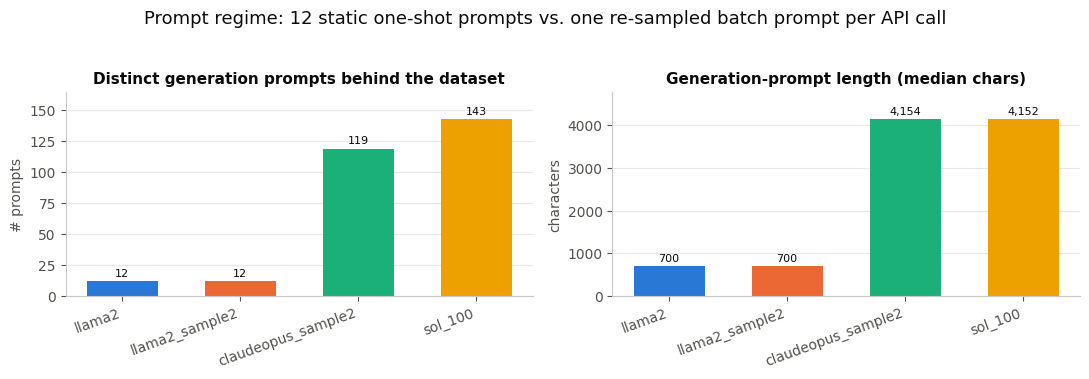

In [10]:
prompt_stats = []
for ds in DS_ORDER:
    sub = df[df.dataset == ds]
    if sub["prompt_sha"].notna().any():
        n_prompts = sub["prompt_sha"].nunique()
        per = sub.groupby("prompt_sha", observed=True).size()
        prompt_stats.append({
            "dataset": ds, "prompt regime": "batched JSON, re-sampled per call",
            "distinct prompts": n_prompts,
            "conversations per prompt (median)": per.median(),
            "prompt length, chars (median)": sub["prompt_chars"].median(),
        })
    else:
        prompt_stats.append({
            "dataset": ds, "prompt regime": "static, one conversation per call",
            "distinct prompts": len(LLAMA_PROMPTS),
            "conversations per prompt (median)": len(sub) / len(LLAMA_PROMPTS),
            "prompt length, chars (median)": np.median([len(p) for p in LLAMA_PROMPTS.values()]),
        })

prompt_summary = pd.DataFrame(prompt_stats).set_index("dataset")
display(prompt_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col, title in zip(
    axes,
    ["distinct prompts", "prompt length, chars (median)"],
    ["Distinct generation prompts behind the dataset", "Generation-prompt length (median chars)"],
):
    vals = prompt_summary[col].astype(float)
    ax.bar(range(len(vals)), vals, color=[PALETTE[d] for d in prompt_summary.index], width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(prompt_summary.index, rotation=20, ha="right")
    label_bars(ax, fmt="{:,.0f}")
    style_axes(ax, title=title)
axes[0].set_ylabel("# prompts")
axes[1].set_ylabel("characters")
fig.suptitle("Prompt regime: 12 static one-shot prompts vs. one re-sampled batch prompt per API call", y=1.04)
plt.tight_layout()
plt.show()

## 4 · Volume — how much data is in each dataset

`text_sha` counts *unique conversation text*: the number that matters for training, since duplicate
files add rows without adding information.

,conversations (files),unique conversation texts,duplicate rows,duplicate rate,total words
dataset,,,,,
llama2,602,362,240,39.9%,"212,596"
llama2_sample2,362,362,0,0.0%,"126,838"
claudeopus_sample2,761,761,0,0.0%,"281,646"
sol_100,858,858,0,0.0%,"317,337"


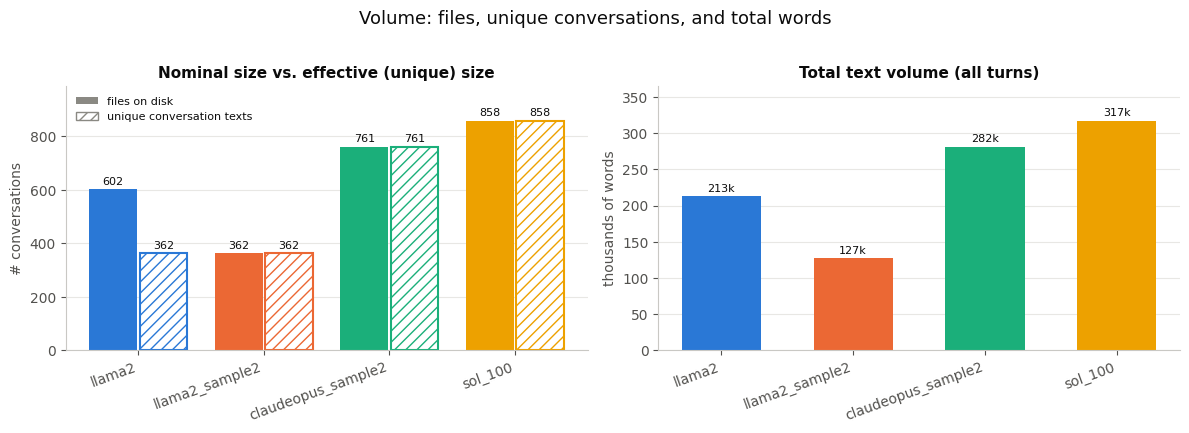

In [11]:
volume = pd.DataFrame({
    "conversations (files)": df.groupby("dataset", observed=True).size(),
    "unique conversation texts": df.groupby("dataset", observed=True)["text_sha"].nunique(),
})
volume["duplicate rows"] = volume["conversations (files)"] - volume["unique conversation texts"]
volume["duplicate rate"] = volume["duplicate rows"] / volume["conversations (files)"]
volume["total words"] = df.groupby("dataset", observed=True)["total_words"].sum()
display(volume.style.format({"duplicate rate": "{:.1%}", "total words": "{:,.0f}",
                             "conversations (files)": "{:,.0f}", "unique conversation texts": "{:,.0f}"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

x = np.arange(len(DS_ORDER))
ax = axes[0]
ax.bar(x - 0.2, volume["conversations (files)"], width=0.38,
       color=[PALETTE[d] for d in DS_ORDER])
ax.bar(x + 0.2, volume["unique conversation texts"], width=0.38,
       color="white", edgecolor=[PALETTE[d] for d in DS_ORDER], linewidth=1.5, hatch="///")
label_bars(ax, fmt="{:,.0f}")
ax.set_xticks(x)
ax.set_xticklabels(DS_ORDER, rotation=20, ha="right")
ax.legend(
    [plt.Rectangle((0, 0), 1, 1, facecolor=FAINT),
     plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor=FAINT, hatch="///")],
    ["files on disk", "unique conversation texts"], loc="upper left", fontsize=8)
style_axes(ax, ylabel="# conversations", title="Nominal size vs. effective (unique) size")

ax = axes[1]
ax.bar(x, volume["total words"] / 1000, color=[PALETTE[d] for d in DS_ORDER], width=0.6)
label_bars(ax, fmt="{:,.0f}k")
ax.set_xticks(x)
ax.set_xticklabels(DS_ORDER, rotation=20, ha="right")
style_axes(ax, ylabel="thousands of words", title="Total text volume (all turns)")

fig.suptitle("Volume: files, unique conversations, and total words", y=1.02)
plt.tight_layout()
plt.show()

## 5 · Label distribution — attribute × level

This is the distribution that matters for probe training: each attribute is a 3-way classification
problem, so within an attribute the three levels should be near-equal, and the four attributes should
be comparable in size.

In [12]:
counts = (df.groupby(["dataset", "attribute", "level"], observed=True).size()
            .unstack("level").fillna(0).astype(int))
counts = counts[[c for c in LEVEL_ORDER if c in counts.columns]]
counts["total"] = counts.sum(axis=1)
display(counts)

level                                 low  medium  neutral  high  total
dataset            attribute                                           
llama2             gullibility         52      50        0    50    152
                   rationality         50      50        0    50    150
                   seriousness         50      50        0    50    150
                   certainty_seeking   50       0       50    50    150
llama2_sample2     gullibility         32      30        0    30     92
                   rationality         30      30        0    30     90
                   seriousness         30      30        0    30     90
                   certainty_seeking   30       0       30    30     90
claudeopus_sample2 gullibility         64      66        0    63    193
                   rationality         64      64        0    64    192
                   seriousness         63      64        0    64    191
                   certainty_seeking   60       0       63    62    185
sol_100            gullibility         72      72        0    72    216
                   rationality         72      72        0    72    216
                   seriousness         72      72        0    72    216
                   certainty_seeking   70       0       70    70    210

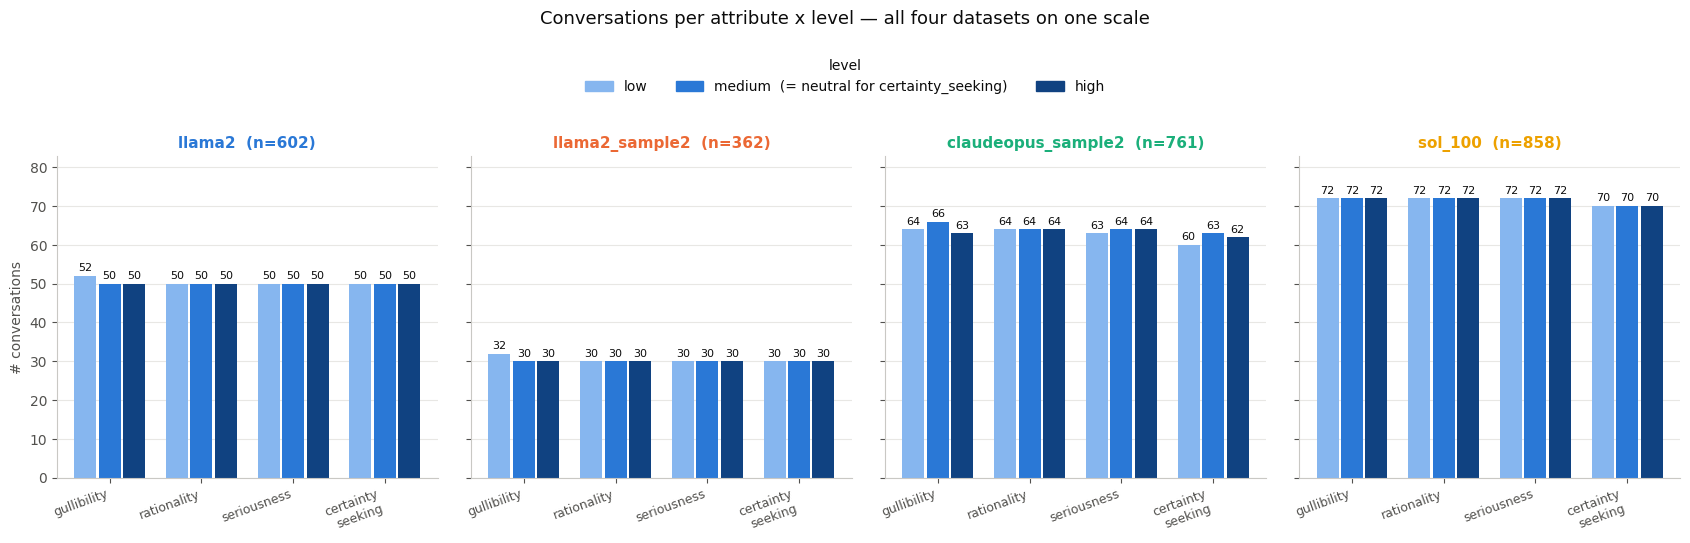

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6), sharey=True)
for ax, ds in zip(axes, DS_ORDER):
    piv = (df[df.dataset == ds].groupby(["attribute", "level_slot"], observed=True).size()
             .unstack("level_slot").reindex(columns=SLOT_ORDER).fillna(0).astype(int))
    xs = np.arange(len(piv.index))
    width = 0.8 / len(SLOT_ORDER)
    for j, lv in enumerate(SLOT_ORDER):
        ax.bar(xs + (j - 1) * width, piv[lv], width=width * 0.9, color=SLOT_COLOR[lv], label=lv)
    label_bars(ax, fmt="{:.0f}", fontsize=8)
    ax.set_xticks(xs)
    ax.set_xticklabels([a.replace("certainty_seeking", "certainty\nseeking") for a in piv.index],
                       rotation=20, ha="right", fontsize=9)
    style_axes(ax, title=f"{ds}  (n={len(df[df.dataset == ds]):,})")
    ax.title.set_color(PALETTE[ds])
axes[0].set_ylabel("# conversations")
handles = [plt.Rectangle((0, 0), 1, 1, color=SLOT_COLOR[lv]) for lv in SLOT_ORDER]
fig.legend(handles, [SLOT_LABEL[lv] for lv in SLOT_ORDER], title="level",
           loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.09))
fig.suptitle("Conversations per attribute x level — all four datasets on one scale", y=1.17)
plt.tight_layout()
plt.show()

attribute,gullibility,rationality,seriousness,certainty_seeking
dataset,,,,
llama2,3.8%,0.0%,0.0%,0.0%
llama2_sample2,6.2%,0.0%,0.0%,0.0%
claudeopus_sample2,4.5%,0.0%,1.6%,4.8%
sol_100,0.0%,0.0%,0.0%,0.0%


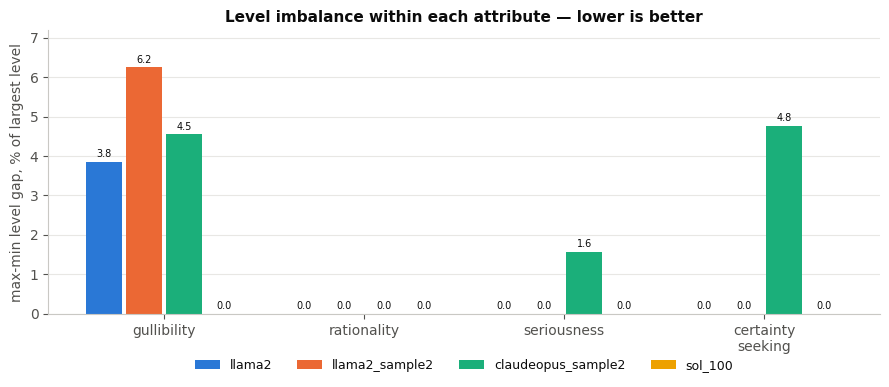

In [14]:
# Balance measured directly: within each attribute, how far is the biggest level from the smallest?
imb = (counts.drop(columns="total")
       .replace(0, np.nan)
       .assign(imbalance=lambda d: (d.max(axis=1) - d.min(axis=1)) / d.max(axis=1))["imbalance"]
       .unstack("attribute"))
display(imb.style.format("{:.1%}").set_caption(
    "Level imbalance within each attribute (0% = perfectly balanced 3-way split)"))

fig, ax = plt.subplots(figsize=(9, 4))
xs = np.arange(len(ATTRS))
width = 0.8 / len(DS_ORDER)
for j, ds in enumerate(DS_ORDER):
    vals = [imb.loc[ds, a] * 100 for a in ATTRS]
    ax.bar(xs + (j - 1.5) * width, vals, width=width * 0.9, color=PALETTE[ds], label=ds)
label_bars(ax, fmt="{:.1f}", fontsize=7)
ax.set_xticks(xs)
ax.set_xticklabels([a.replace("_", "\n") for a in ATTRS])
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=9)
style_axes(ax, ylabel="max-min level gap, % of largest level",
           title="Level imbalance within each attribute — lower is better")
plt.tight_layout()
plt.show()

## 6 · Duplicates — nominal size vs. effective size

Hashing the full conversation text shows how much of each dataset is actually distinct content.

attribute,gullibility,rationality,seriousness,certainty_seeking
dataset,,,,
llama2,39.5%,40.0%,40.0%,40.0%
llama2_sample2,0.0%,0.0%,0.0%,0.0%
claudeopus_sample2,0.0%,0.0%,0.0%,0.0%
sol_100,0.0%,0.0%,0.0%,0.0%


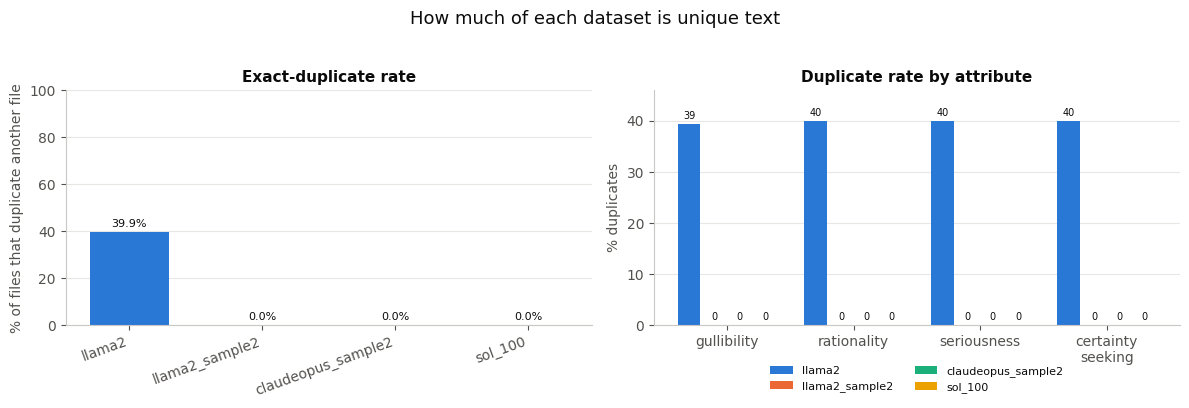

In [15]:
dup_by_attr = (df.groupby(["dataset", "attribute"], observed=True)["text_sha"]
                 .apply(lambda s: s.duplicated(keep="first").mean())
                 .unstack("attribute"))
display(dup_by_attr.style.format("{:.1%}").set_caption("Duplicate rate by dataset x attribute"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
rates = volume["duplicate rate"] * 100
ax.bar(np.arange(len(rates)), rates, color=[PALETTE[d] for d in rates.index], width=0.6)
label_bars(ax, fmt="{:.1f}%")
ax.set_xticks(np.arange(len(rates)))
ax.set_xticklabels(rates.index, rotation=20, ha="right")
ax.set_ylim(0, 100)
style_axes(ax, ylabel="% of files that duplicate another file",
           title="Exact-duplicate rate")

ax = axes[1]
xs = np.arange(len(ATTRS))
width = 0.8 / len(DS_ORDER)
for j, ds in enumerate(DS_ORDER):
    ax.bar(xs + (j - 1.5) * width, [dup_by_attr.loc[ds, a] * 100 for a in ATTRS],
           width=width * 0.9, color=PALETTE[ds], label=ds)
label_bars(ax, fmt="{:.0f}", fontsize=7)
ax.set_xticks(xs)
ax.set_xticklabels([a.replace("_", "\n") for a in ATTRS])
ax.legend(ncol=2, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.13))
style_axes(ax, ylabel="% duplicates", title="Duplicate rate by attribute")
fig.suptitle("How much of each dataset is unique text", y=1.03)
plt.tight_layout()
plt.show()

In [16]:
# datasets_llama2_sample2 is datasets_llama2 with exact duplicates removed —
# check that claim directly against the hashes.
sha_llama = set(df[df.dataset == "llama2"]["text_sha"])
sha_sample2 = set(df[df.dataset == "llama2_sample2"]["text_sha"])
print(f"llama2:          {len(df[df.dataset == 'llama2']):>4} files, {len(sha_llama):>4} unique texts")
print(f"llama2_sample2:  {len(df[df.dataset == 'llama2_sample2']):>4} files, {len(sha_sample2):>4} unique texts")
print(f"same set of unique texts: {sha_llama == sha_sample2}")

overlap = pd.DataFrame(
    [[len(set(df[df.dataset == a]['text_sha']) & set(df[df.dataset == b]['text_sha']))
      for b in DS_ORDER] for a in DS_ORDER],
    index=DS_ORDER, columns=DS_ORDER,
)
display(overlap.style.set_caption("Shared unique conversation texts between datasets"))

llama2:           602 files,  362 unique texts
llama2_sample2:   362 files,  362 unique texts
same set of unique texts: True


,llama2,llama2_sample2,claudeopus_sample2,sol_100
llama2,362,362,0,0
llama2_sample2,362,362,0,0
claudeopus_sample2,0,0,761,0
sol_100,0,0,0,858


## 7 · Conversation shape — turns per conversation

,min,median,mean,max,std,mode
dataset,,,,,,
llama2,4,12.0,12.17,22,2.73,12
llama2_sample2,4,12.0,12.09,22,2.74,12
claudeopus_sample2,5,6.0,6.42,8,0.83,6
sol_100,6,8.0,7.75,12,1.26,8


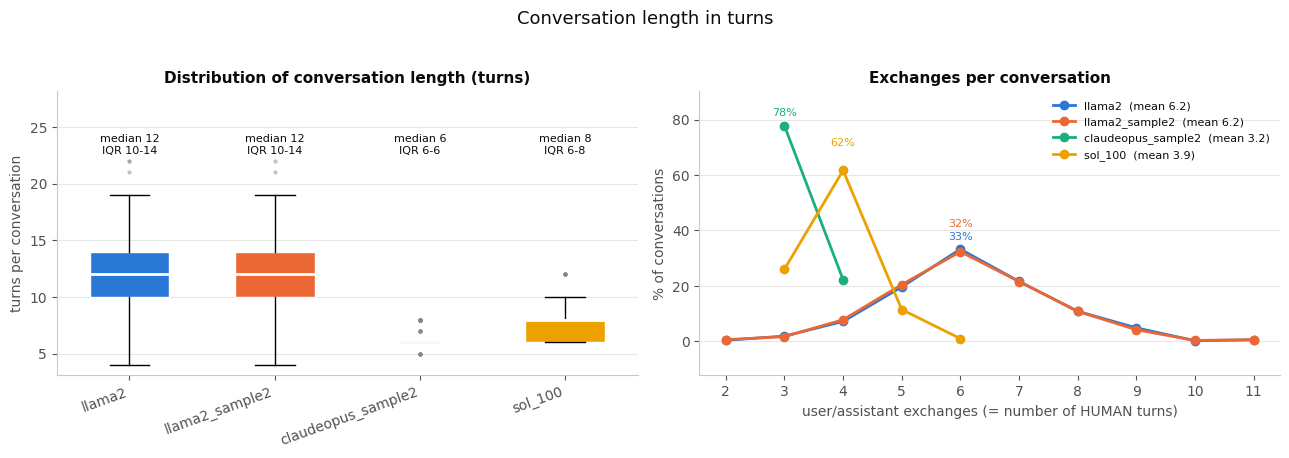

In [17]:
turn_summary = df.groupby("dataset", observed=True)["n_turns"].agg(
    ["min", "median", "mean", "max", "std"]).round(2)
turn_summary["mode"] = df.groupby("dataset", observed=True)["n_turns"].agg(lambda s: s.mode().iat[0])
display(turn_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
data = [df[df.dataset == ds]["n_turns"].values for ds in DS_ORDER]
bp = ax.boxplot(data, tick_labels=DS_ORDER, patch_artist=True, widths=0.55,
                medianprops=dict(color="white", linewidth=2),
                flierprops=dict(marker="o", markersize=3, markerfacecolor=FAINT,
                                markeredgecolor="none", alpha=0.5))
for patch, ds in zip(bp["boxes"], DS_ORDER):
    patch.set_facecolor(PALETTE[ds])
    patch.set_edgecolor("white")
top = df["n_turns"].max()
for i, ds in enumerate(DS_ORDER):
    s = df[df.dataset == ds]["n_turns"]
    ax.annotate(f"median {s.median():.0f}\nIQR {s.quantile(.25):.0f}-{s.quantile(.75):.0f}",
                xy=(i + 1, top), xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=8, color=INK)
ax.set_ylim(top=top * 1.28)
ax.set_xticklabels(DS_ORDER, rotation=20, ha="right")
style_axes(ax, ylabel="turns per conversation", title="Distribution of conversation length (turns)")

ax = axes[1]
# Counted in exchanges (= user turns): a conversation can end on a dangling user turn,
# so raw turn counts are sometimes odd and sometimes even, which puts a spurious
# zig-zag in the shape. Exchanges take integer values with no such parity gap.
for ds in DS_ORDER:
    vals = df[df.dataset == ds]["n_human"]
    share = vals.value_counts(normalize=True).sort_index() * 100
    ax.plot(share.index, share.values, marker="o", markersize=6, linewidth=2,
            color=PALETTE[ds], label=f"{ds}  (mean {vals.mean():.1f})")
    peak = share.idxmax()
    ax.annotate(f"{share.max():.0f}%", xy=(peak, share.max()),
                xytext=(0, 7 + 11 * (DS_ORDER.index(ds) % 2)), textcoords="offset points",
                ha="center", fontsize=8, color=PALETTE[ds])
ax.set_xticks(range(int(df["n_human"].min()), int(df["n_human"].max()) + 1))
ax.legend(fontsize=8)
ax.margins(y=0.16)
style_axes(ax, ylabel="% of conversations", title="Exchanges per conversation")
ax.set_xlabel("user/assistant exchanges (= number of HUMAN turns)")
plt.tight_layout()
fig.suptitle("Conversation length in turns", y=1.03)
plt.tight_layout()
plt.show()

## 8 · Message length — words per turn

The probe reads the residual stream after the user's last message, so *how much user text* each
conversation carries is the quantity that most directly sets how much signal there is to read.

,human_words_per_conv,assistant_words_per_conv,words_per_human_turn,words_per_assistant_turn,total_words_per_conv
dataset,,,,,
llama2,128.0,225.2,21.3,39.2,353.1
llama2_sample2,128.2,222.2,21.5,38.9,350.4
claudeopus_sample2,82.1,288.0,25.6,90.7,370.1
sol_100,117.9,252.0,30.5,65.4,369.9


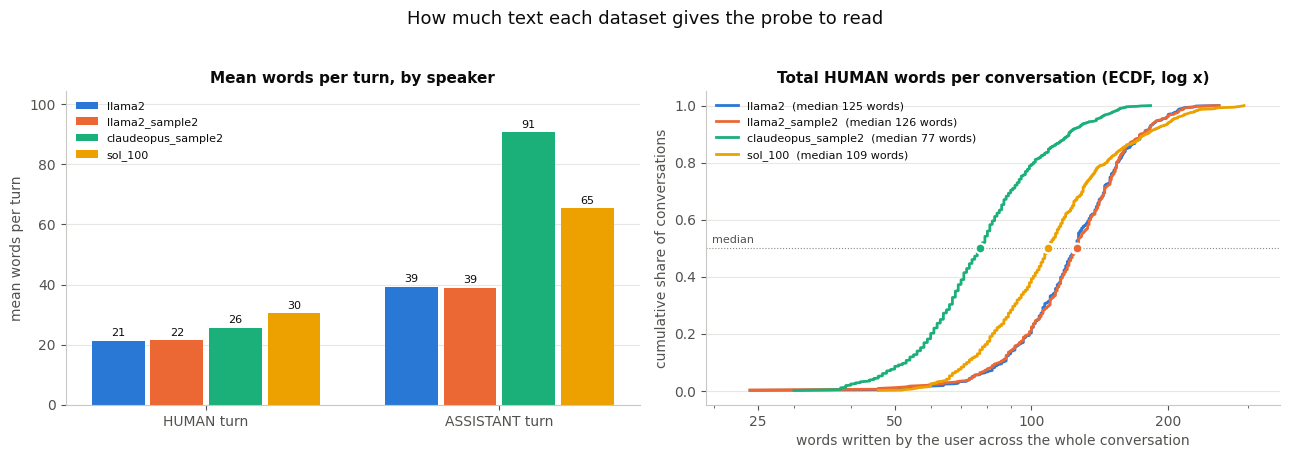

In [18]:
len_summary = df.groupby("dataset", observed=True).agg(
    human_words_per_conv=("human_words", "mean"),
    assistant_words_per_conv=("assistant_words", "mean"),
    words_per_human_turn=("mean_human_words", "mean"),
    words_per_assistant_turn=("mean_assistant_words", "mean"),
    total_words_per_conv=("total_words", "mean"),
).round(1)
display(len_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
xs = np.arange(2)
width = 0.8 / len(DS_ORDER)
for j, ds in enumerate(DS_ORDER):
    vals = [len_summary.loc[ds, "words_per_human_turn"], len_summary.loc[ds, "words_per_assistant_turn"]]
    ax.bar(xs + (j - 1.5) * width, vals, width=width * 0.9, color=PALETTE[ds], label=ds)
label_bars(ax, fmt="{:.0f}", fontsize=8)
ax.set_xticks(xs)
ax.set_xticklabels(["HUMAN turn", "ASSISTANT turn"])
ax.legend(fontsize=8)
style_axes(ax, ylabel="mean words per turn", title="Mean words per turn, by speaker")

ax = axes[1]
medians = {}
for ds in DS_ORDER:
    vals = np.sort(df[df.dataset == ds]["human_words"].values)
    y = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, y, color=PALETTE[ds], linewidth=2,
            label=f"{ds}  (median {np.median(vals):.0f} words)")
    med = np.median(vals)
    medians[ds] = med
    # mark where each curve crosses the median line rather than labelling in place,
    # which would collide — the medians are in the legend.
    ax.plot([med], [0.5], marker="o", markersize=7, color=PALETTE[ds],
            markeredgecolor="white", markeredgewidth=1.5, zorder=5)
ax.set_xscale("log")
ax.set_xticks([25, 50, 100, 200, 400, 800])
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set_xlim(df["human_words"].min() * 0.8, df["human_words"].max() * 1.2)
ax.axhline(0.5, color=FAINT, linewidth=0.8, linestyle=":")
ax.annotate("median", xy=(ax.get_xlim()[0], 0.5), xytext=(4, 4), textcoords="offset points",
            fontsize=8, color=MUTED)
ax.legend(fontsize=8, loc="upper left")
style_axes(ax, ylabel="cumulative share of conversations",
           title="Total HUMAN words per conversation (ECDF, log x)")
ax.set_xlabel("words written by the user across the whole conversation")
fig.suptitle("How much text each dataset gives the probe to read", y=1.03)
plt.tight_layout()
plt.show()

## 9 · Vocabulary and topic diversity

Type-token ratio is computed on a **fixed 200,000-token sample per dataset** — TTR falls
mechanically as a corpus grows, so comparing raw TTR across datasets of different size would measure
size, not diversity. Topic labels exist only in the `.json` sidecars, so they are available for the
two API datasets only.

,tokens sampled,distinct word types,type-token ratio,hapax rate,distinct topics (sidecar),topic reuse (convs per topic)
dataset,,,,,,
llama2,"200,000","6,524",0.0326,24.6%,n/a,n/a
llama2_sample2,"131,216","6,713",0.0512,37.3%,n/a,n/a
claudeopus_sample2,"200,000","12,673",0.0634,37.7%,654,1.16
sol_100,"200,000","12,882",0.0644,32.7%,840,1.02


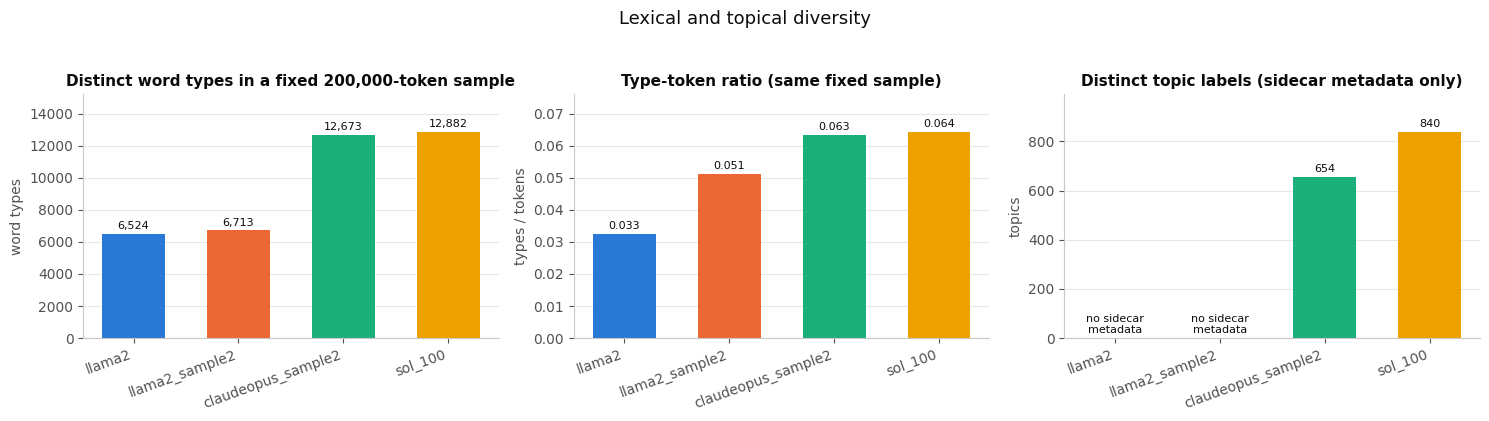

In [19]:
SAMPLE_TOKENS = 200_000
rng = random.Random(0)

vocab_rows = []
for ds in DS_ORDER:
    tokens = []
    texts = df[df.dataset == ds]["text"].tolist()
    rng.shuffle(texts)
    for t in texts:
        tokens.extend(w.lower() for w in WORD_RE.findall(t))
        if len(tokens) >= SAMPLE_TOKENS:
            break
    tokens = tokens[:SAMPLE_TOKENS]
    counts_t = Counter(tokens)
    topics = df[(df.dataset == ds) & df.topic.notna()]["topic"]
    vocab_rows.append({
        "dataset": ds,
        "tokens sampled": len(tokens),
        "distinct word types": len(counts_t),
        "type-token ratio": len(counts_t) / len(tokens),
        "hapax rate": sum(1 for c in counts_t.values() if c == 1) / len(counts_t),
        "distinct topics (sidecar)": topics.nunique() if len(topics) else np.nan,
        "topic reuse (convs per topic)": len(topics) / topics.nunique() if len(topics) else np.nan,
    })

vocab = pd.DataFrame(vocab_rows).set_index("dataset")
display(vocab.style.format({"tokens sampled": "{:,.0f}", "distinct word types": "{:,.0f}",
                            "type-token ratio": "{:.4f}", "hapax rate": "{:.1%}",
                            "distinct topics (sidecar)": "{:,.0f}",
                            "topic reuse (convs per topic)": "{:.2f}"}, na_rep="n/a"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
specs = [
    ("distinct word types", "{:,.0f}", f"Distinct word types in a fixed {SAMPLE_TOKENS:,}-token sample", "word types"),
    ("type-token ratio", "{:.3f}", "Type-token ratio (same fixed sample)", "types / tokens"),
    ("distinct topics (sidecar)", "{:,.0f}", "Distinct topic labels (sidecar metadata only)", "topics"),
]
for ax, (col, fmt, title, ylab) in zip(axes, specs):
    vals = vocab[col].astype(float)
    plotted = vals.fillna(0)
    ax.bar(np.arange(len(vals)), plotted, color=[PALETTE[d] for d in vals.index], width=0.6)
    ax.bar_label(ax.containers[0],
                 labels=[fmt.format(v) if pd.notna(v) else "no sidecar\nmetadata" for v in vals],
                 padding=2, fontsize=8, color=INK)
    ax.margins(y=0.18)
    ax.set_xticks(np.arange(len(vals)))
    ax.set_xticklabels(vals.index, rotation=20, ha="right")
    style_axes(ax, ylabel=ylab, title=title)
fig.suptitle("Lexical and topical diversity", y=1.04)
plt.tight_layout()
plt.show()

## 10 · Generation-quality checks

Three checks that apply identically to all four datasets:

* **role alternation** — turns must run `HUMAN, ASSISTANT, HUMAN, …` starting with `HUMAN`; a
  violation is a generator artifact, not a level signal.
* **too-short conversations** — `gen_llama_dataset.py` rejects anything under 2 user/assistant pairs
  (`MIN_TURN_PAIRS`); the API generators ask for at least 3.
* **label leakage** — the user's own turns should never contain a label word for the trait
  (`leak_stems` in the shared attribute spec). Computed here from the text for every dataset, so the
  four are directly comparable.

,conversations,role-alternation violations,< 3 exchanges,conversations with a leaked trait word,role-alternation violations (%),< 3 exchanges (%),a leaked trait word (%)
dataset,,,,,,,
llama2,602,10,2,45,1.7%,0.3%,7.5%
llama2_sample2,362,8,2,36,2.2%,0.6%,9.9%
claudeopus_sample2,761,0,0,34,0.0%,0.0%,4.5%
sol_100,858,0,0,16,0.0%,0.0%,1.9%


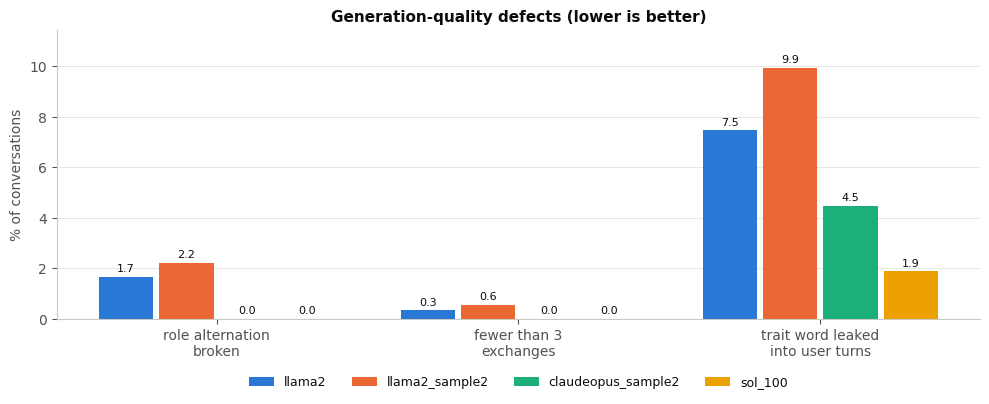

In [20]:
qa = pd.DataFrame({
    "conversations": df.groupby("dataset", observed=True).size(),
    "role-alternation violations": df.groupby("dataset", observed=True)["alt_ok"].apply(lambda s: (~s).sum()),
    "< 3 exchanges": df.groupby("dataset", observed=True)["n_human"].apply(lambda s: (s < 3).sum()),
    "conversations with a leaked trait word": df.groupby("dataset", observed=True)["n_leak_stems"].apply(lambda s: (s > 0).sum()),
})
for col in qa.columns[1:]:
    qa[col.replace("conversations with ", "") + " (%)"] = qa[col] / qa["conversations"] * 100
display(qa.style.format("{:.0f}", subset=qa.columns[:4]).format("{:.1f}%", subset=qa.columns[4:]))

fig, ax = plt.subplots(figsize=(10, 4.2))
metrics = ["role-alternation violations", "< 3 exchanges", "conversations with a leaked trait word"]
xs = np.arange(len(metrics))
width = 0.8 / len(DS_ORDER)
for j, ds in enumerate(DS_ORDER):
    vals = [qa.loc[ds, m] / qa.loc[ds, "conversations"] * 100 for m in metrics]
    ax.bar(xs + (j - 1.5) * width, vals, width=width * 0.9, color=PALETTE[ds], label=ds)
label_bars(ax, fmt="{:.1f}", fontsize=8)
ax.set_xticks(xs)
ax.set_xticklabels(["role alternation\nbroken", "fewer than 3\nexchanges", "trait word leaked\ninto user turns"])
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.16), fontsize=9)
style_axes(ax, ylabel="% of conversations",
           title="Generation-quality defects (lower is better)")
plt.tight_layout()
plt.show()

In [21]:
leaked = df[df.n_leak_stems > 0]
if len(leaked):
    display(leaked.groupby(["dataset", "attribute"], observed=True).size()
            .unstack("attribute").fillna(0).astype(int)
            .style.set_caption("Conversations with a trait label word in the user's turns"))
    display(Counter(s for row in leaked["leak_stems"] for s in row.split(",")).most_common(10))

attribute,gullibility,rationality,seriousness,certainty_seeking
dataset,,,,
llama2,15,0,30,0
llama2_sample2,10,0,26,0
claudeopus_sample2,8,14,12,0
sol_100,2,8,4,2


[('serious', 52),
 ('trust', 34),
 ('reasonab', 16),
 ('formal', 11),
 ('jok', 8),
 ('skeptic', 6),
 ('silly', 5),
 ('logic', 3),
 ('rational', 3),
 ('ambigu', 1)]

## 11 · Side-by-side summary

Every metric above, one column per dataset.

In [22]:
summary = pd.DataFrame(index=DS_ORDER)
summary["generator model"] = [DATASETS[d][1] for d in DS_ORDER]
summary["generation script"] = [DATASETS[d][2] for d in DS_ORDER]
summary["prompt regime"] = prompt_summary["prompt regime"]
summary["distinct prompts"] = prompt_summary["distinct prompts"].astype(int)
summary["conversations (files)"] = volume["conversations (files)"]
summary["unique conversation texts"] = volume["unique conversation texts"]
summary["duplicate rate"] = (volume["duplicate rate"] * 100).round(1).astype(str) + "%"
summary["attributes x levels covered"] = [
    f'{df[df.dataset == d]["attribute"].nunique()} x 3' for d in DS_ORDER]
summary["conversations per attribute (median)"] = [
    df[df.dataset == d].groupby("attribute", observed=True).size().median() for d in DS_ORDER]
summary["worst level imbalance"] = (imb.max(axis=1) * 100).round(1).astype(str) + "%"
summary["turns per conversation (median)"] = turn_summary["median"]
summary["turns per conversation (mean)"] = turn_summary["mean"]
summary["words per HUMAN turn (mean)"] = len_summary["words_per_human_turn"]
summary["words per ASSISTANT turn (mean)"] = len_summary["words_per_assistant_turn"]
summary["HUMAN words per conversation (mean)"] = len_summary["human_words_per_conv"]
summary["total words"] = volume["total words"].map("{:,.0f}".format)
summary[f"word types / {SAMPLE_TOKENS//1000}k tokens"] = vocab["distinct word types"].map("{:,.0f}".format)
summary["type-token ratio"] = vocab["type-token ratio"].round(4)
summary["distinct sidecar topics"] = vocab["distinct topics (sidecar)"].map(
    lambda v: f"{v:,.0f}" if pd.notna(v) else "n/a (no sidecars)")
summary["role-alternation violations"] = qa["role-alternation violations"]
summary["trait-word leaks"] = qa["conversations with a leaked trait word"]

summary.T

,llama2,llama2_sample2,claudeopus_sample2,sol_100
generator model,Llama-2-13b-chat,Llama-2-13b-chat,claude-opus-5,gpt-5.6-sol
generation script,scripts/gen_llama_dataset.py,scripts/build_llama2_sample2.py,scripts/gen_opus_data100.py,scripts/gen_sol_data100.py
prompt regime,"static, one conversation per call","static, one conversation per call","batched JSON, re-sampled per call","batched JSON, re-sampled per call"
distinct prompts,12,12,119,143
conversations (files),602,362,761,858
unique conversation texts,362,362,761,858
duplicate rate,39.9%,0.0%,0.0%,0.0%
attributes x levels covered,4 x 3,4 x 3,4 x 3,4 x 3
conversations per attribute (median),150.0,90.0,191.5,216.0
worst level imbalance,3.8%,6.2%,4.8%,0.0%


### 11.1 · The counts table, in full

Conversations per dataset × attribute × level — the distribution table behind every chart above.

In [23]:
full_counts = (df.groupby(["attribute", "level", "dataset"], observed=True).size()
                 .unstack("dataset").fillna(0).astype(int))
full_counts["all datasets"] = full_counts.sum(axis=1)
display(full_counts)

print("\ncolumn totals:")
display(full_counts.sum().to_frame("conversations").T)

dataset                    llama2  llama2_sample2  claudeopus_sample2  sol_100  all datasets
attribute         level                                                                     
gullibility       low          52              32                  64       72           220
                  medium       50              30                  66       72           218
                  high         50              30                  63       72           215
rationality       low          50              30                  64       72           216
                  medium       50              30                  64       72           216
                  high         50              30                  64       72           216
seriousness       low          50              30                  63       72           215
                  medium       50              30                  64       72           216
                  high         50              30                  64       72           216
certainty_seeking low          50              30                  60       70           210
                  neutral      50              30                  63       70           213
                  high         50              30                  62       70           212


column totals:


dataset,llama2,llama2_sample2,claudeopus_sample2,sol_100,all datasets
conversations,602,362,761,858,2583


## 12 · What the comparison shows

Read the summary table above alongside these charts:

* **Size.** `sol_100` is the largest corpus on disk, `claudeopus_sample2` next (its run is
  incomplete — `run.log` shows dropped batches), then `llama2`. But `llama2`'s file count is inflated
  by exact duplicates: its *effective* size equals `llama2_sample2` exactly, which is what
  `build_llama2_sample2.py` was written to expose.
* **Balance.** All four are near-balanced 3-way splits within each attribute; the API datasets carry
  small imbalances only where a batch was dropped mid-run.
* **Vocabulary.** At an equal 200k-token sample, `llama2` shows far fewer word types than
  `llama2_sample2` — the same corpus, minus duplicates. That gap *is* the duplication: repeated text
  spends tokens without adding types. Both trail the two API datasets substantially.
* **Prompt regime.** `llama2` is generated from 12 static prompts, one conversation per call, so its
  diversity has to come entirely from sampling. The API datasets re-sample topic/shape/voice seeds
  into every batch prompt, and record the exact prompt per conversation — which is why they carry
  more distinct word types at equal token count.
* **`claudeopus_sample2` vs `sol_100` is close to a controlled comparison.** The two generator
  scripts are the same program with a different API client, and they share a base seed, so 115 of
  the 119 opus batch prompts also appear in `sol_100`. Differences between those two datasets are
  therefore mostly attributable to the model, not the prompt — which is not true of any comparison
  involving `llama2`.
* **Shape.** The two regimes produce visibly different conversations: `llama2` runs long and variable
  (median 6 exchanges, tail out to 11), while the batched API datasets cluster tightly on the 3-4
  exchanges their prompt asks for — but with far longer assistant turns. Compare
  turns-per-conversation and words-per-turn before pooling datasets for training:
  a probe trained on pooled sources sees whichever source contributes the longer, more numerous user
  turns as the dominant signal.
* **Quality.** The leak and alternation panels are the ones to watch when swapping a generator — they
  are computed identically for all four, from the same shared `leak_stems` spec.

The dataset directories are inputs to `src/train_reading_probe.py` / `src/train_control_probe.py` via
`--dataset_dirs`; note those scripts **pool** every directory passed into one combined train/test
split, so any imbalance above compounds across the sources you pool.